In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                           classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import time

In [ ]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

print("Описание набора данных Iris:")
print(iris.DESCR[:500])

Описание набора данных Iris:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= =====


In [ ]:
df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris['target'] = y_iris
df_iris['species'] = df_iris['target'].apply(lambda x: target_names_iris[x])

print("Первые 5 строк данных:")
print(df_iris.head())

print("\nИнформация о данных:")
print(df_iris.info())

print("\nСтатистика данных:")
print(df_iris.describe())

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width

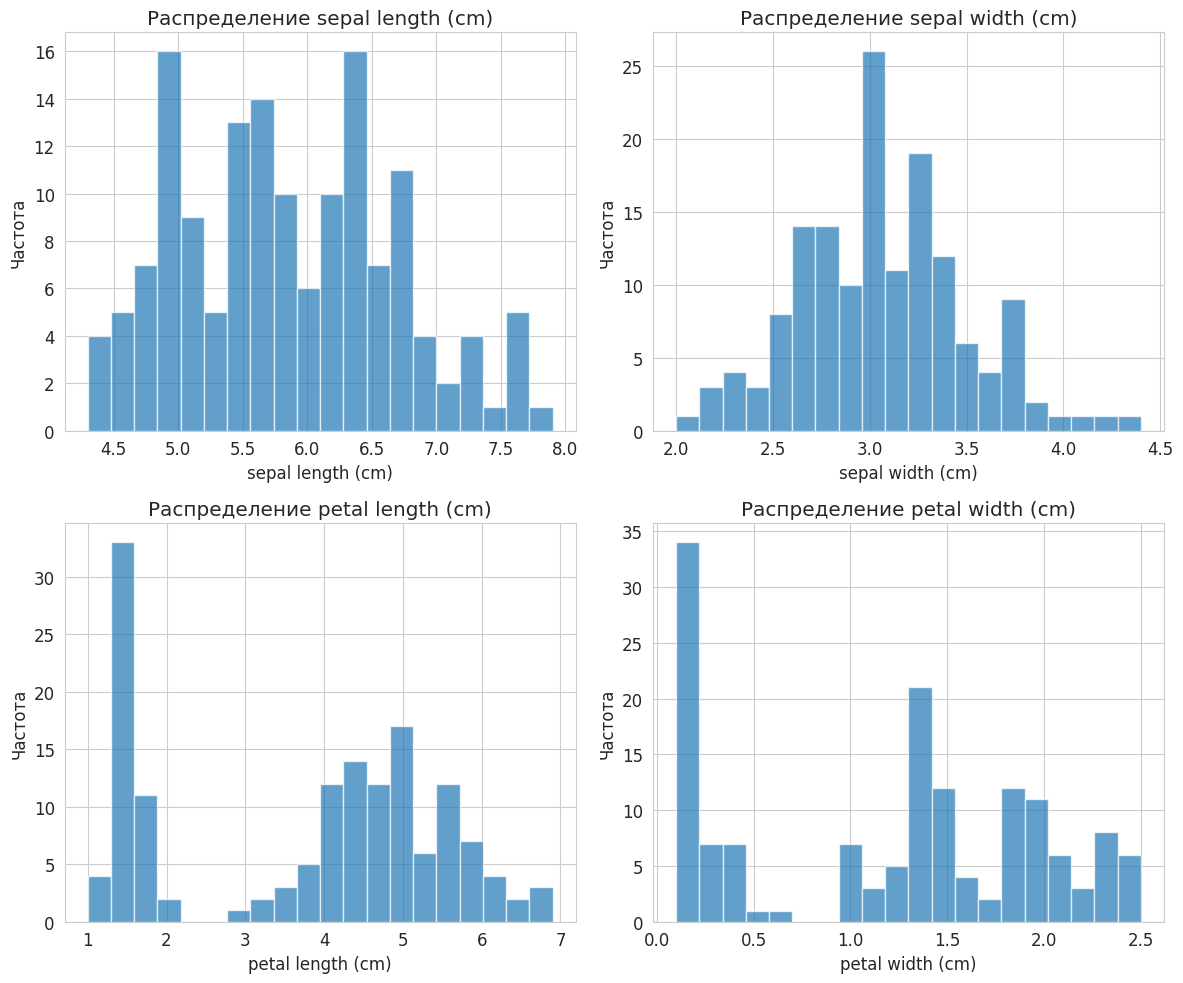

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(feature_names_iris):
    df_iris[feature].hist(bins=20, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

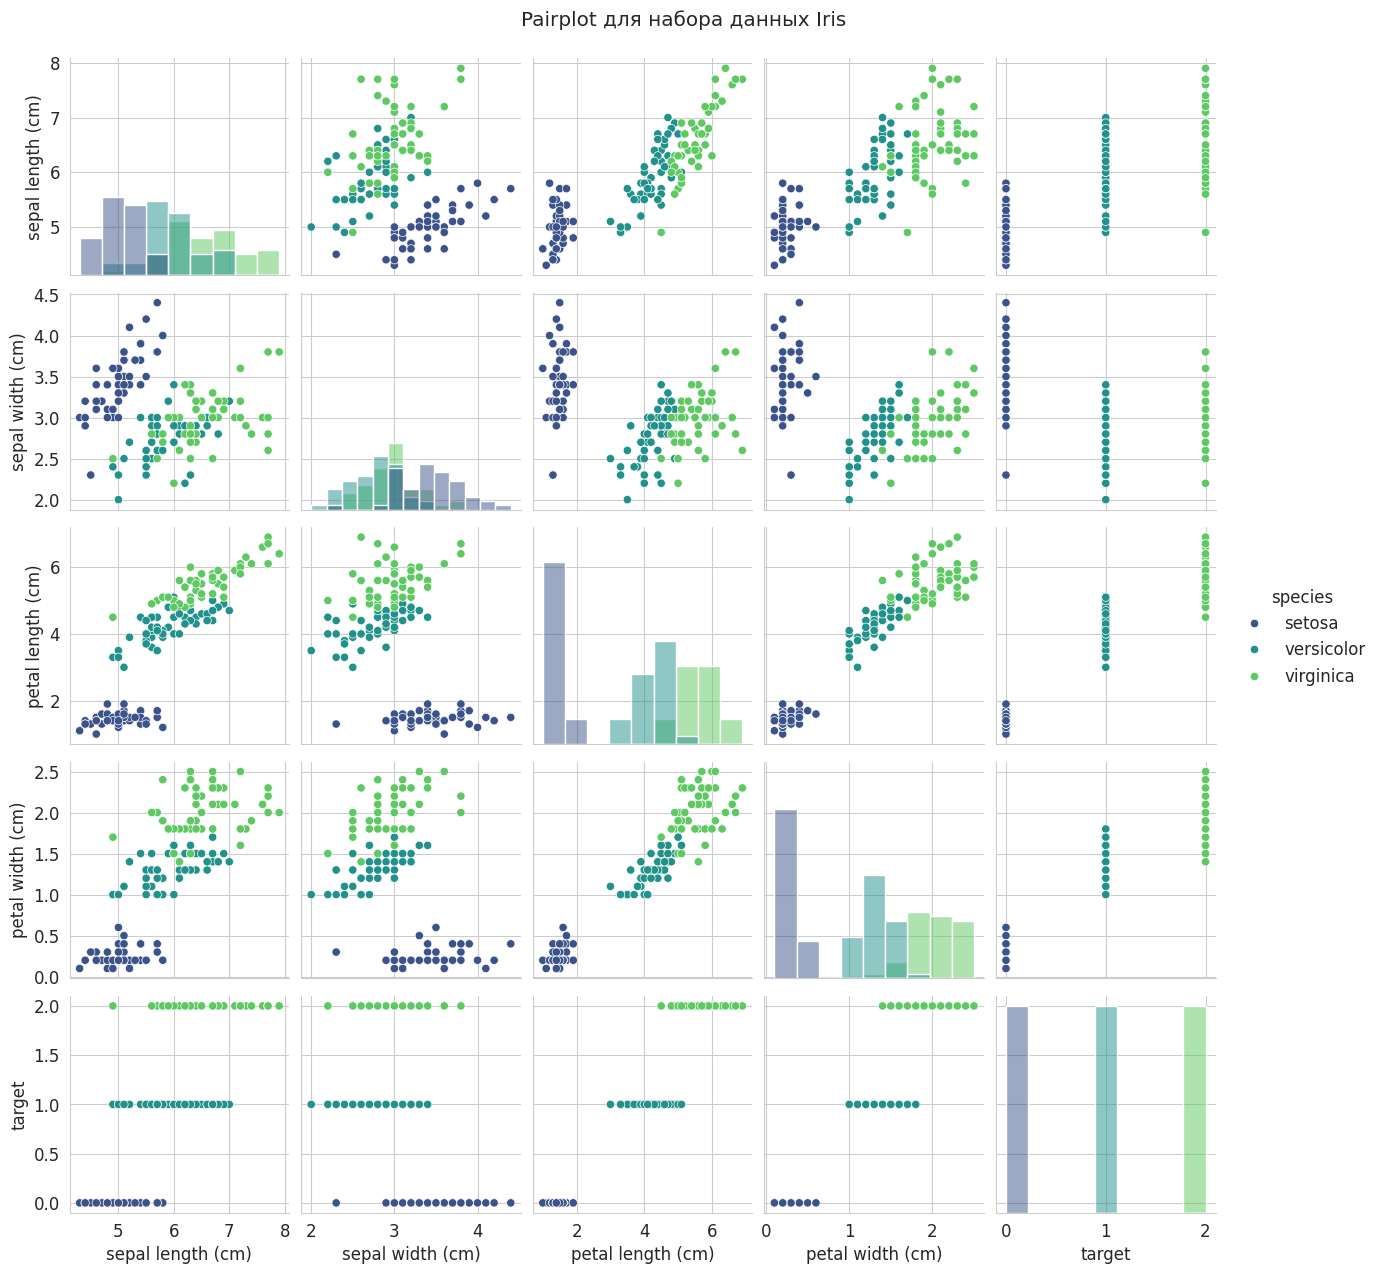

In [ ]:
plt.figure(figsize=(12, 10))
sns.pairplot(df_iris, hue='species', palette='viridis', diag_kind='hist')
plt.suptitle('Pairplot для набора данных Iris', y=1.02)
plt.show()

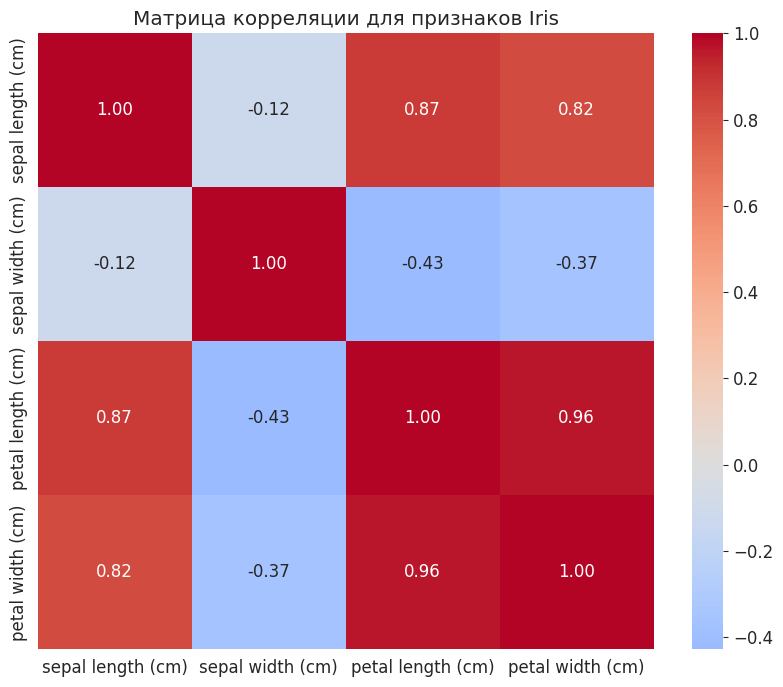

In [ ]:
corr_matrix_iris = df_iris[feature_names_iris].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_iris, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Матрица корреляции для признаков Iris')
plt.show()

In [ ]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print(f"Размер обучающей выборки: {X_train_iris.shape}")
print(f"Размер тестовой выборки: {X_test_iris.shape}")

Размер обучающей выборки: (120, 4)
Размер тестовой выборки: (30, 4)


In [ ]:
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

In [ ]:
k_values = [3, 5, 7]
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_iris_scaled, y_train_iris)
    y_pred = knn.predict(X_test_iris_scaled)
    accuracy = accuracy_score(y_test_iris, y_pred)
    accuracy_scores.append(accuracy)
    print(f"Точность для k={k}: {accuracy:.4f}")

Точность для k=3: 0.9333
Точность для k=5: 0.9333
Точность для k=7: 0.9667


In [ ]:
k_range = range(1, 20)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_iris_scaled, y_train_iris)

    train_pred = knn.predict(X_train_iris_scaled)
    test_pred = knn.predict(X_test_iris_scaled)

    train_scores.append(accuracy_score(y_train_iris, train_pred))
    test_scores.append(accuracy_score(y_test_iris, test_pred))

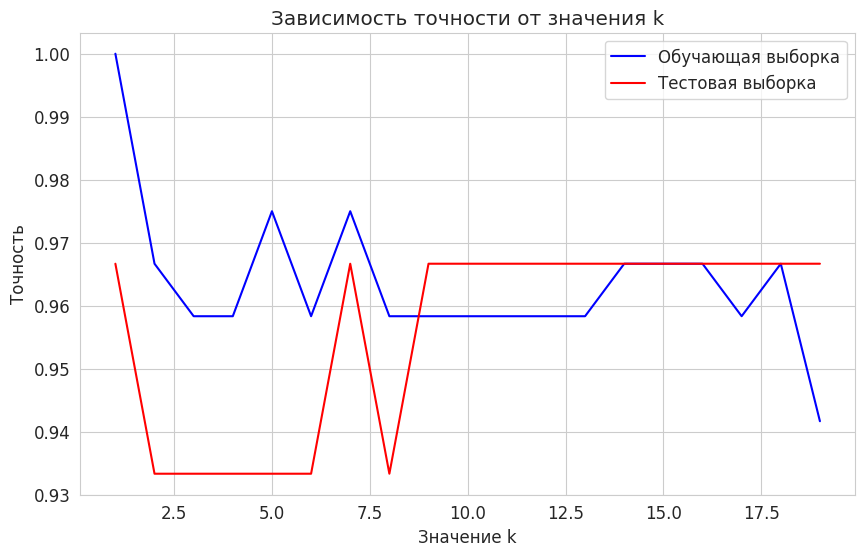

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, 'b-', label='Обучающая выборка')
plt.plot(k_range, test_scores, 'r-', label='Тестовая выборка')
plt.xlabel('Значение k')
plt.ylabel('Точность')
plt.title('Зависимость точности от значения k')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
optimal_k_iris = k_range[np.argmax(test_scores)]
print(f"Оптимальное значение k: {optimal_k_iris}")

# Обучение финальной модели с оптимальным k
final_knn_iris = KNeighborsClassifier(n_neighbors=optimal_k_iris)
final_knn_iris.fit(X_train_iris_scaled, y_train_iris)
y_pred_final_iris = final_knn_iris.predict(X_test_iris_scaled)

final_accuracy = accuracy_score(y_test_iris, y_pred_final_iris)
print(f"Точность финальной модели: {final_accuracy:.4f}")

Оптимальное значение k: 1
Точность финальной модели: 0.9667


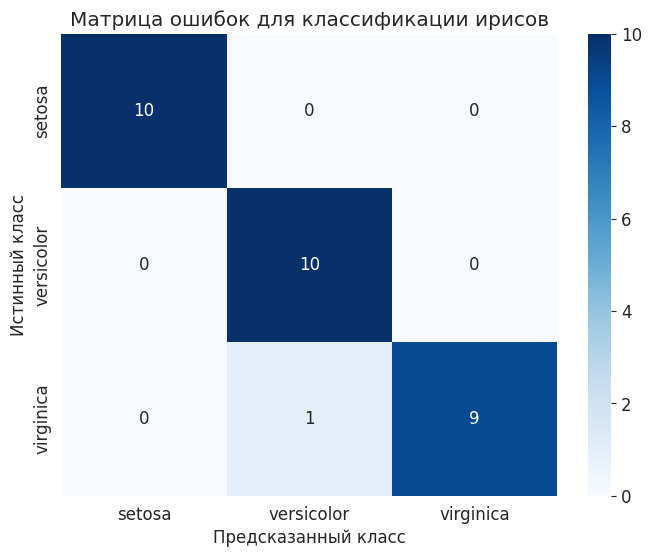

Отчет о классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
cm_iris = confusion_matrix(y_test_iris, y_pred_final_iris)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_iris,
            yticklabels=target_names_iris)
plt.title('Матрица ошибок для классификации ирисов')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# %%
# Отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_iris, y_pred_final_iris,
                          target_names=target_names_iris))